# Population Trends in Species vs Genus

This notebook compares **hindfoot length** and **weight** at different aggregation levels:
- Species
- Genus

The goal is to see how aggregation changes the average values and the variability of the data. 

By the end of this section, you will be able to understand how aggregating on specific criteria may allow the user to limit the number of rows and still gain valuable insight, or accidentally hide important trends that are hiding in sub-sections of the data. Visualizations as well as tables showcasing the differences in different criterias will help display the cost and significance of different aggregations.

---

## Load the data

This cell reads the merged project dataset so we can work with hindfoot length and weight.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../output/merged_full.csv")
df.head()

,record_id,month,day,year,plot_id,note1,species_id,sex,hindfoot_length,weight,genus,species_name,taxa,plot_type,note1_meaning
0,63,8,19,1977,3.0,NaN,DM,M,35.0,40.0,Dipodomys,merriami,Rodent,Long-term Krat Exclosure,NaN
1,64,8,19,1977,7.0,NaN,DM,M,37.0,48.0,Dipodomys,merriami,Rodent,Rodent Exclosure,NaN
2,65,8,19,1977,4.0,NaN,DM,F,34.0,29.0,Dipodomys,merriami,Rodent,Control,NaN
3,66,8,19,1977,4.0,NaN,DM,F,35.0,46.0,Dipodomys,merriami,Rodent,Control,NaN
4,67,8,19,1977,7.0,NaN,DM,M,35.0,36.0,Dipodomys,merriami,Rodent,Rodent Exclosure,NaN


## Keep only the columns we need

Narrowing down the dataset to the columns that are necessary for this analysis allows us to understand the data easier, without additional distractions. Seeing the specific columns we'll be using also allows us to get an understanding of the domain and data types.

Here, we are selecting the **genus**, **species name**, **hindfoot length**, and **weight** columns.

In [2]:
analysis_df = df[['genus', 'species_name', 'hindfoot_length', 'weight']].copy()

for col in ['genus', 'species_name']:
    analysis_df[col] = analysis_df[col].astype('string').str.strip()

analysis_df = analysis_df.dropna(subset=['genus', 'species_name']).copy()
analysis_df = analysis_df.loc[
    analysis_df['genus'].ne('')
    & analysis_df['species_name'].ne('')
].copy()

analysis_df

,genus,species_name,hindfoot_length,weight
0,Dipodomys,merriami,35.0,40.0
1,Dipodomys,merriami,37.0,48.0
2,Dipodomys,merriami,34.0,29.0
3,Dipodomys,merriami,35.0,46.0
4,Dipodomys,merriami,35.0,36.0
...,...,...,...,...
70912,Dipodomys,merriami,36.0,47.0
70913,Chaetodipus,penicillatus,20.0,16.0
70914,Chaetodipus,penicillatus,19.0,14.0
70915,Dipodomys,merriami,36.0,42.0


### Species Specific Dataset

Aggregating the dataset based on the species of each rodent allows us to find the average values for each species. Here we can create a new dataset called **species_df** which narrows our dataset down to **24 rows**. This allows us to see the average values easier, but can also reveal trends surroundng the rodent species that we couldn't see from looking at the raw dataset. 

In [3]:
species_df = analysis_df.groupby(['species_name', 'genus'], as_index=False).agg(
    mean_hindfoot_length=('hindfoot_length', 'mean'),
    mean_weight=('weight', 'mean'))

species_df.sort_values('mean_weight', ascending=False).reset_index(drop=True)

,species_name,genus,mean_hindfoot_length,mean_weight
0,spectabilis,Dipodomys,49.952722,119.907354
1,hispidus,Sigmodon,28.632568,88.753653
2,fulviventer,Sigmodon,25.970509,69.042895
3,ochrognathus,Sigmodon,25.600000,55.375000
4,ordii,Dipodomys,35.442572,49.038285
5,merriami,Dipodomys,35.794027,43.524222
6,baileyi,Chaetodipus,25.936415,31.689940
7,leucogaster,Onychomys,20.316541,30.881203
8,hispidus,Perognathus,24.928571,30.214286
9,sp.,Dipodomys,34.000000,27.000000


### Genus Specific Dataset

The same process we took for species can also be done for the different genus groups of rodents. By aggregating by genus type, we go to **8 rows** of average values. This new dataset grouped by genus types is called **genus_df**.

In [4]:
genus_df = analysis_df.groupby(['genus'], as_index=False).agg(
    mean_hindfoot_length=('hindfoot_length', 'mean'),
    mean_weight=('weight', 'mean'))

genus_df.sort_values('mean_weight', ascending=False).reset_index(drop=True)

,genus,mean_hindfoot_length,mean_weight
0,Sigmodon,27.383408,79.014574
1,Dipodomys,36.898725,51.095179
2,Onychomys,19.997171,25.598408
3,Chaetodipus,22.967558,22.488865
4,Peromyscus,19.953160,21.793061
5,Reithrodontomys,16.324913,10.772642
6,Baiomys,13.258486,9.501305
7,Perognathus,15.597639,8.341367


### Visualize the Differences

In order to easier understand how the average values of hindfoot length and weight of the rodents can differ, we can visualize the data. 

The plot below shows the average values as a horizontal line, while each sub-species in that genus is plotted as a point. These points are connected to the genus average by a vertical line, showcasing the size between the species and genus averages. 

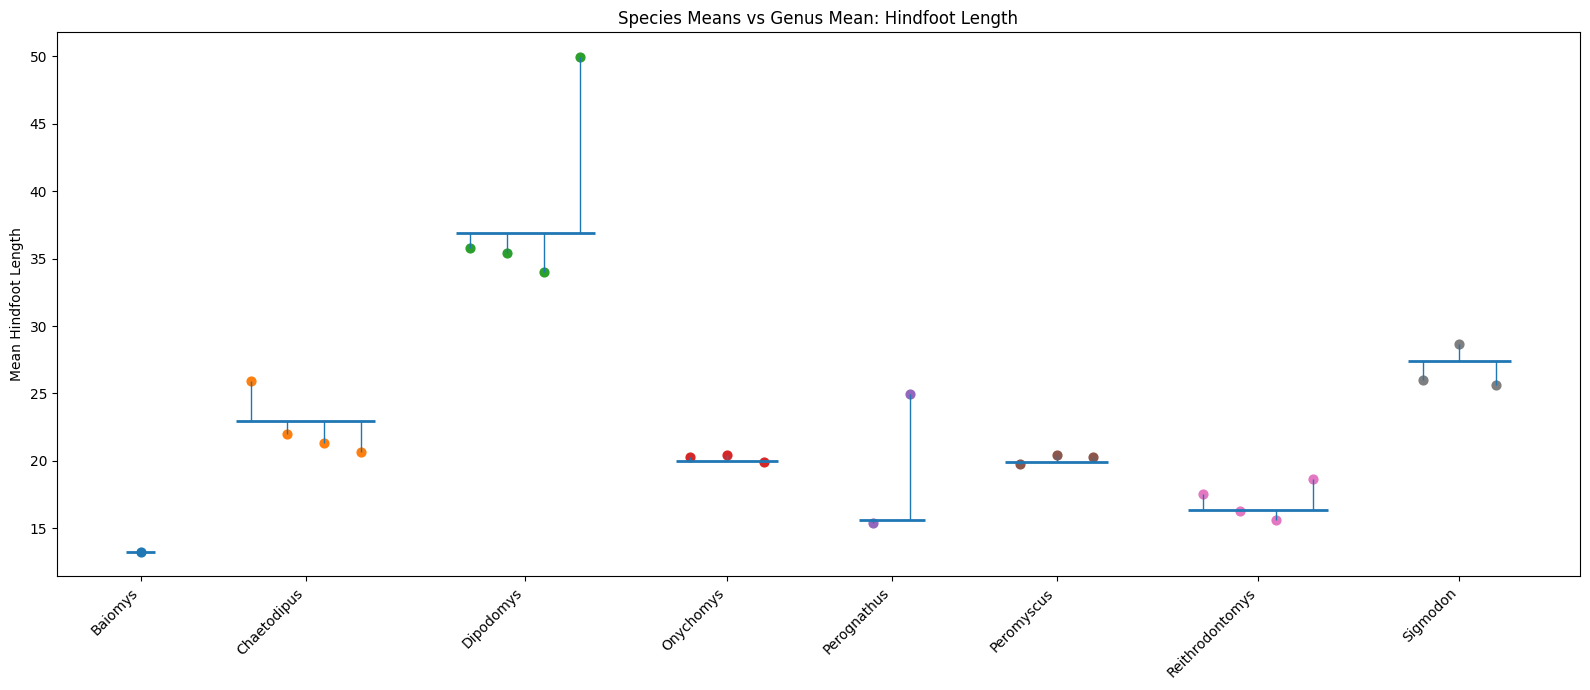

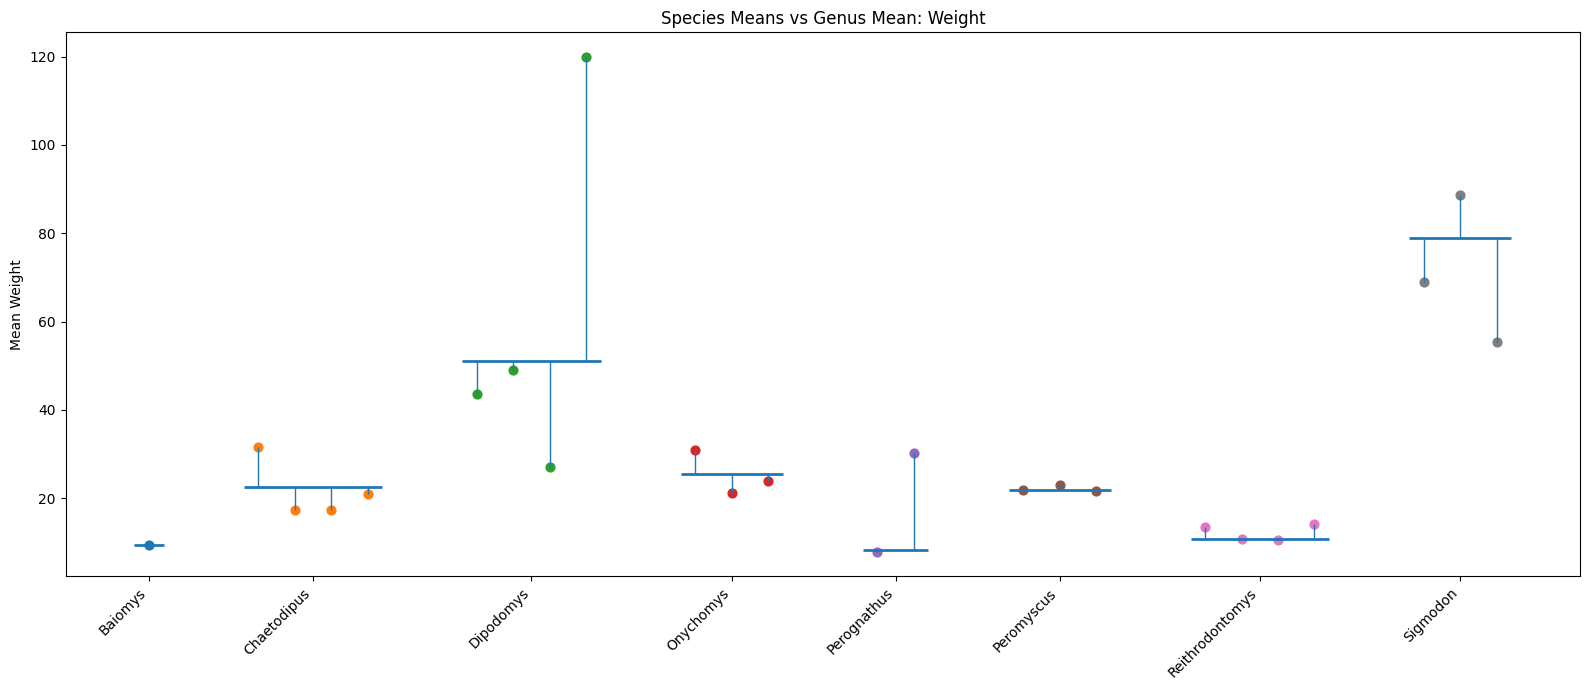

In [ ]:
# FIG 1.1

# Hindfoot length plot
hindfoot_plot_df = species_df[['genus', 'species_name', 'mean_hindfoot_length']].rename(
    columns={'mean_hindfoot_length': 'species_value'}
).merge(
    genus_df[['genus', 'mean_hindfoot_length']].rename(columns={'mean_hindfoot_length': 'genus_value'}),
    on='genus',
    how='inner'
)

hindfoot_plot_df = hindfoot_plot_df.dropna(subset=['species_value', 'genus_value']).copy()
hindfoot_plot_df = hindfoot_plot_df.sort_values(['genus', 'species_name']).reset_index(drop=True)

genera = hindfoot_plot_df['genus'].drop_duplicates().tolist()
genus_centers = {}
genus_line_ranges = {}
current_x = 0
gap = 2

for genus in genera:
    group = hindfoot_plot_df[hindfoot_plot_df['genus'] == genus].copy()
    n = len(group)
    positions = list(range(current_x, current_x + n))
    genus_centers[genus] = sum(positions) / len(positions)
    genus_line_ranges[genus] = (positions[0] - 0.4, positions[-1] + 0.4)
    hindfoot_plot_df.loc[group.index, 'x'] = positions
    current_x += n + gap

fig, ax = plt.subplots(figsize=(16, 7))

for genus in genera:
    group = hindfoot_plot_df[hindfoot_plot_df['genus'] == genus]
    genus_mean = group['genus_value'].iloc[0]
    x_min, x_max = genus_line_ranges[genus]
    ax.hlines(y=genus_mean, xmin=x_min, xmax=x_max, linewidth=2)

    for _, row in group.iterrows():
        ax.vlines(
            x=row['x'],
            ymin=min(row['species_value'], genus_mean),
            ymax=max(row['species_value'], genus_mean),
            linewidth=1
        )

    ax.scatter(group['x'], group['species_value'], s=40)

ax.set_xticks([genus_centers[g] for g in genera])
ax.set_xticklabels(genera, rotation=45, ha='right')
ax.set_ylabel('Mean Hindfoot Length')
ax.set_title('Species Means vs Genus Mean: Hindfoot Length')
plt.tight_layout()
plt.show()

# FIG 1.2

# Weight plot
weight_plot_df = species_df[['genus', 'species_name', 'mean_weight']].rename(
    columns={'mean_weight': 'species_value'}
).merge(
    genus_df[['genus', 'mean_weight']].rename(columns={'mean_weight': 'genus_value'}),
    on='genus',
    how='inner'
)

weight_plot_df = weight_plot_df.dropna(subset=['species_value', 'genus_value']).copy()
weight_plot_df = weight_plot_df.sort_values(['genus', 'species_name']).reset_index(drop=True)

genera = weight_plot_df['genus'].drop_duplicates().tolist()
genus_centers = {}
genus_line_ranges = {}
current_x = 0
gap = 2

for genus in genera:
    group = weight_plot_df[weight_plot_df['genus'] == genus].copy()
    n = len(group)
    positions = list(range(current_x, current_x + n))
    genus_centers[genus] = sum(positions) / len(positions)
    genus_line_ranges[genus] = (positions[0] - 0.4, positions[-1] + 0.4)
    weight_plot_df.loc[group.index, 'x'] = positions
    current_x += n + gap

fig, ax = plt.subplots(figsize=(16, 7))

for genus in genera:
    group = weight_plot_df[weight_plot_df['genus'] == genus]
    genus_mean = group['genus_value'].iloc[0]
    x_min, x_max = genus_line_ranges[genus]
    ax.hlines(y=genus_mean, xmin=x_min, xmax=x_max, linewidth=2)

    for _, row in group.iterrows():
        ax.vlines(
            x=row['x'],
            ymin=min(row['species_value'], genus_mean),
            ymax=max(row['species_value'], genus_mean),
            linewidth=1
        )

    ax.scatter(group['x'], group['species_value'], s=40)

ax.set_xticks([genus_centers[g] for g in genera])
ax.set_xticklabels(genera, rotation=45, ha='right')
ax.set_ylabel('Mean Weight')
ax.set_title('Species Means vs Genus Mean: Weight')
plt.tight_layout()
plt.show()

Based on our plots, we can see that some genus and species averages are relatively close to eachother. Genera like **Onychomys**, **Peromyscus**, and **Peithrodontomys** have average genus values that are relatively close to all of their sub-section species. This could allow a user who is analyzing this dataset to make assumptions for the genus as a whole, since it's data is linked close together.

Other genera like **Dipodomys**, **Perognathus**, and **Sigmodon** have average genus values that do not lie closely with the sub-section species averages. Dipodomys especially, has outliers that greatly differ from the genus average. This measn that these species maynot be as closely linked to the genus, meaning aggregating by the genus for data analysis may hide important features in those species. This could cause a loss of narrative for specific species.

## Analytical Comparison of Species and Genus means

This section summarizes the average difference between each species mean and its genus mean for every genus.

- Larger average differences may suggest that species within the same genus are meaningfully different, so aggregating only at the genus level may hide important biological variation.
- Very small average differences may suggest that species in that genus behave similarly enough that genus-level aggregation may be acceptable when faster computation is more important than fine-grained detail.

In [6]:
hindfoot_analysis = hindfoot_plot_df.copy()
hindfoot_analysis['absolute_difference'] = (hindfoot_analysis['species_value'] - hindfoot_analysis['genus_value']).abs()

weight_analysis = weight_plot_df.copy()
weight_analysis['absolute_difference'] = (weight_analysis['species_value'] - weight_analysis['genus_value']).abs()

hindfoot_summary = (hindfoot_analysis.groupby('genus', as_index=False).agg(
        hindfoot_genus_mean=('genus_value', 'first'),
        hindfoot_average_species_difference=('absolute_difference', 'mean'),
        hindfoot_max_species_difference=('absolute_difference', 'max'),
        species_count=('species_name', 'nunique')
    )
)

weight_summary = (weight_analysis.groupby('genus', as_index=False).agg(
        weight_genus_mean=('genus_value', 'first'),
        weight_average_species_difference=('absolute_difference', 'mean'),
        weight_max_species_difference=('absolute_difference', 'max')
    )
)

genus_difference_summary = hindfoot_summary.merge(weight_summary, on='genus', how='inner')

hindfoot_threshold_low = genus_difference_summary['hindfoot_average_species_difference'].median()
weight_threshold_low = genus_difference_summary['weight_average_species_difference'].median()
hindfoot_threshold_high = genus_difference_summary['hindfoot_average_species_difference'].quantile(0.75)
weight_threshold_high = genus_difference_summary['weight_average_species_difference'].quantile(0.75)


genus_difference_summary = genus_difference_summary.sort_values(
    ['weight_average_species_difference', 'hindfoot_average_species_difference'],
    ascending=False
).reset_index(drop=True)

genus_difference_summary = genus_difference_summary[['genus', 'species_count', 'hindfoot_genus_mean', 
                                                     'hindfoot_average_species_difference', 'hindfoot_max_species_difference', 
                                                     'weight_genus_mean', 'weight_average_species_difference', 
                                                     'weight_max_species_difference']]

genus_difference_summary.round(3)

,genus,species_count,hindfoot_genus_mean,hindfoot_average_species_difference,hindfoot_max_species_difference,weight_genus_mean,weight_average_species_difference,weight_max_species_difference
0,Dipodomys,4,36.899,4.628,13.054,51.095,25.634,68.812
1,Sigmodon,3,27.383,1.482,1.783,79.015,14.450,23.640
2,Perognathus,2,15.598,4.764,9.331,8.341,11.167,21.873
3,Chaetodipus,4,22.968,1.982,2.969,22.489,5.218,9.201
4,Onychomys,3,19.997,0.274,0.403,25.598,3.768,5.283
5,Reithrodontomys,4,16.325,1.076,2.342,10.773,1.630,3.394
6,Peromyscus,3,19.953,0.333,0.515,21.793,0.460,1.242
7,Baiomys,1,13.258,0.000,0.000,9.501,0.000,0.000


This table shows the numbers behind the insights found in the plots above. 

The **Dipodomys** genus sees large differences in both the hindfoot length and weight averages. This tells us that the genus may have species that differ from eachother and it would be irresponsible to aggregate based on genus.

## Conclusion

- Aggregating by species keeps more detail and helps show which species are influencing the overall trends.
- Aggregating by genus makes the dataset easier to read, but it can hide important differences between species.
- **Peromyscus**, **Onychomys**, and **Reithrodontomys** had species averages that stayed close to their genus averages, so genus-level summaries are more useful for these groups.
- **Dipodomys**, **Sigmodon**, and **Perognathus** had larger differences between species and genus averages, meaning genus-level aggregation may be misleading for these groups.
- **Baiomys** only had one species in the dataset, so its species and genus averages were the same.

Overall, aggregation is useful for simplifying data, but it should be used carefully so important species-level trends are not hidden.


### TODO

Need to add code to ouput the plots into an images folder in the output directory

Add code as a helper function in seperate notebook and then import from static output directory

create heatmap of stds of species values vs genus 

add a dotted line for the mean across the genera as well

box and whisker plot

make dot size based on observation count per species (do it for dots with big outliers)

maybe add scatterplot with normalized weight and hindfoot length values

add code comments throughout this cell

instead of full table, show the specific species with high variance and closer grouped values

another notebook with full tables, gives the option for people to explore.

add note about single specieis in a genus

add count of actual observations in each species/genus in a seperate table